# Political Compass chat analysis — primary models


    This complete release notebook covers four Gemma chat variants and the four
    primary Qwen checkpoints in matched think/no-think protocols. It uses the
    released 21,600-row configuration table; text-level proposition diagnostics
    remain in `qualitative-analysis/`. When available, the table is read from
    the pinned Hugging Face `analysis_ready` download.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ANALYSIS_DIR = Path.cwd()
if not (ANALYSIS_DIR / 'core.py').exists():
    candidates = [Path('tasks/political-compass/analysis').resolve(), Path.cwd().parent]
    ANALYSIS_DIR = next((path for path in candidates if (path / 'core.py').exists()), None)
if ANALYSIS_DIR is None:
    raise FileNotFoundError('Run from the repository root or tasks/political-compass/analysis.')
sys.path.insert(0, str(ANALYSIS_DIR))

from core import (
    GEMMA_MODELS, QWEN_MODELS, PRIMARY_MODELS, IDEOLOGY_ORDER,
    load_mcq_configurations, load_chat_configurations, method_order,
    plot_centroid_grid, qwen_think_outcomes, descriptive_factor_spread,
    plot_sensitivity_heatmap, size_label, analysis_table_path,
    read_analysis_table,
)

sns.set_theme(style='whitegrid', context='notebook')
def source_label(path):
    try: return path.relative_to(ANALYSIS_DIR.parents[2])
    except ValueError: return path
print('Political Compass analysis source:')
print('  MCQ:', source_label(analysis_table_path('pct_configuration_scores')))
print('  chat:', source_label(analysis_table_path('chat_configuration_scores')))

Political Compass analysis source:
  MCQ: /tmp/llm-bias-fresh-analysis/data/analysis_ready/political_compass/pct_configuration_scores.parquet
  chat: /tmp/llm-bias-fresh-analysis/data/analysis_ready/political_compass/chat_configuration_scores.parquet


## Coverage and protocol balance

        Every displayed model/protocol/persona block contains 300 configurations.
        The original exploratory notebook also displayed GaMS and Qwen 0.6B/1.7B;
        those are outside the paper model set and are intentionally absent.

In [2]:
chat = load_chat_configurations()
counts = chat.groupby(['base_model','protocol','ideology'], observed=True).size()
display(pd.Series({'configuration rows':len(chat), 'base models':chat.base_model.nunique(),
                   'model/protocol variants':chat.model_variant.nunique(),
                   'minimum block size':counts.min(), 'maximum block size':counts.max()}).to_frame('value'))
assert len(chat)==21_600 and counts.eq(300).all()
assert set(chat.base_model)==set(PRIMARY_MODELS)

,value
configuration rows,21600
base models,8
model/protocol variants,12
minimum block size,300
maximum block size,300


## Configuration distributions and persona centroids

        Gemma sizes are grouped first, then Qwen no-think sizes, then Qwen
        think sizes. Points are configurations; markers are persona means; the
        ellipses show one standard deviation along covariance axes.

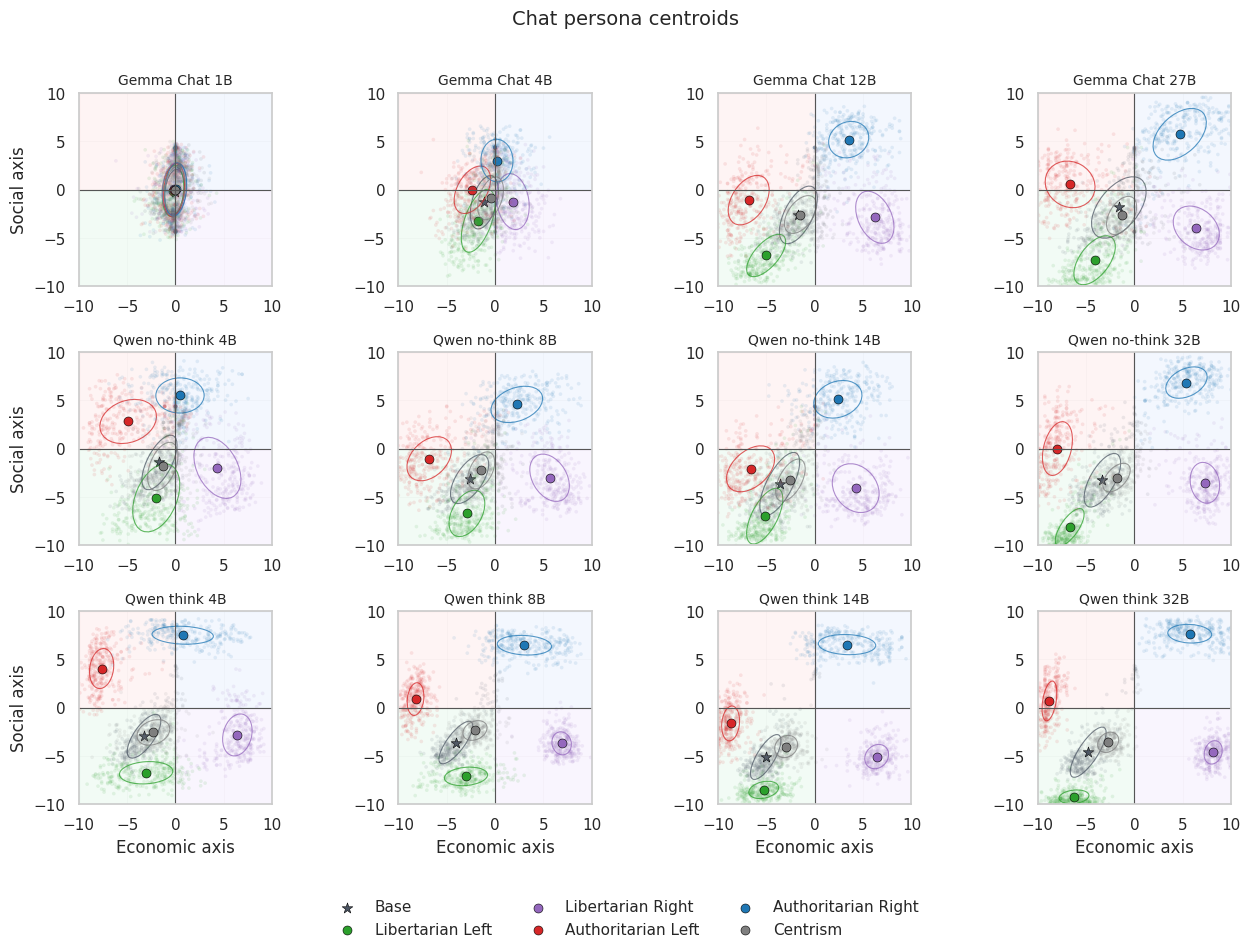

In [3]:
panels=[]
panels += [(f'{m}|standard', f'Gemma Chat {size_label(m)}') for m in GEMMA_MODELS]
panels += [(f'{m}|no_think', f'Qwen no-think {size_label(m)}') for m in QWEN_MODELS]
panels += [(f'{m}|think', f'Qwen think {size_label(m)}') for m in QWEN_MODELS]
fig=plot_centroid_grid(chat,panels,ncols=4,title='Chat persona centroids')
plt.show()

## Response length and classification diagnostics

        Stage-1 tokens measure the visible response before the final candidate
        scoring step. Entropy measures the candidate distribution in Stage 2.
        Neither is a direct measure of rationale quality.

configurations  mean_stage1_tokens  \
base_model     protocol                                       
Qwen3-14B      no_think            1800             147.398   
               think               1800             615.258   
Qwen3-32B      no_think            1800             144.660   
               think               1800             593.440   
Qwen3-4B       no_think            1800             152.240   
               think               1800             717.043   
Qwen3-8B       no_think            1800             165.223   
               think               1800             723.842   
gemma-3-12b-it standard            1800             242.863   
gemma-3-1b-it  standard            1800             129.724   
gemma-3-27b-it standard            1800             239.548   
gemma-3-4b-it  standard            1800             203.082   

                         median_visible_words  mean_entropy  \
base_model     protocol                                       
Qwen3-14B      no_think                92.492         0.020   
               think                   77.710         0.020   
Qwen3-32B      no_think                91.202         0.077   
               think                   82.427         0.054   
Qwen3-4B       no_think                89.435         0.009   
               think                   73.331         0.011   
Qwen3-8B       no_think                95.210         0.025   
               think                   80.403         0.015   
gemma-3-12b-it standard               136.339         0.020   
gemma-3-1b-it  standard                59.355         0.080   
gemma-3-27b-it standard               152.452         0.025   
gemma-3-4b-it  standard               112.911         0.057   

                         mean_target_alignment  
base_model     protocol                         
Qwen3-14B      no_think                  0.690  
               think                     0.748  
Qwen3-32B      no_think                  0.764  
               think                     0.796  
Qwen3-4B       no_think                  0.677  
               think                     0.755  
Qwen3-8B       no_think                  0.690  
               think                     0.762  
gemma-3-12b-it standard                  0.707  
gemma-3-1b-it  standard                  0.494  
gemma-3-27b-it standard                  0.732  
gemma-3-4b-it  standard                  0.589

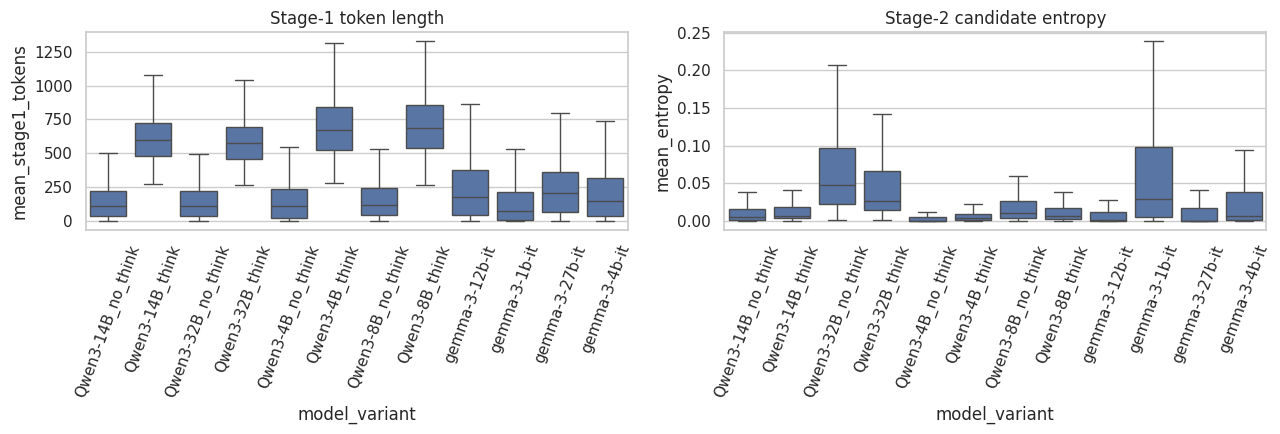

In [4]:
diagnostic=(chat.groupby(['base_model','protocol'],observed=True)
            .agg(configurations=('lhs_row','size'), mean_stage1_tokens=('mean_stage1_tokens','mean'),
                 median_visible_words=('mean_visible_words','median'), mean_entropy=('mean_entropy','mean'),
                 mean_target_alignment=('target_alignment_rate','mean')))
display(diagnostic.round(3))
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
sns.boxplot(data=chat,x='model_variant',y='mean_stage1_tokens',showfliers=False,ax=axes[0])
axes[0].tick_params(axis='x',rotation=70); axes[0].set_title('Stage-1 token length')
sns.boxplot(data=chat,x='model_variant',y='mean_entropy',showfliers=False,ax=axes[1])
axes[1].tick_params(axis='x',rotation=70); axes[1].set_title('Stage-2 candidate entropy')
fig.tight_layout(); plt.show()

## Explicit Stage-1 stance versus Stage-2 classification

        The parser searches the final visible lines of Stage 1 for one
        unambiguous answer label or key, maps both stages back to the canonical
        four choices, and compares them only when both are recoverable. Thus,
        `conditional agreement` is agreement divided by comparable rows—not by
        all generated rows. This checks the answer-mapping step; it does not
        establish that the explanation is faithful or high quality.

In [5]:
agreement=read_analysis_table('chat_stage_agreement_summary')
display(agreement[['model_variant','rows','comparable_rows','comparable_rate',
                   'conditional_agreement_rate']].round(4))
overall=agreement.agreement_rows.sum()/agreement.comparable_rows.sum()
print(f'Overall conditional agreement: {overall:.3%} '
      f'({agreement.agreement_rows.sum():,}/{agreement.comparable_rows.sum():,})')
assert len(agreement)==12 and np.isclose(overall,0.950929,atol=5e-7)

,model_variant,rows,comparable_rows,comparable_rate,conditional_agreement_rate
0,Qwen3-14B_no_think,111600,111386,0.9981,0.9838
1,Qwen3-14B_think,111600,111149,0.9960,0.9920
2,Qwen3-32B_no_think,111600,111397,0.9982,0.9938
3,Qwen3-32B_think,111600,110964,0.9943,0.9966
4,Qwen3-4B_no_think,111600,111166,0.9961,0.9745
5,Qwen3-4B_think,111600,110899,0.9937,0.9923
6,Qwen3-8B_no_think,111600,111471,0.9988,0.9822
7,Qwen3-8B_think,111600,110984,0.9945,0.9930
8,gemma-3-12b-it,111600,105893,0.9489,0.9509
9,gemma-3-1b-it,111600,104967,0.9406,0.7531


Overall conditional agreement: 95.093% (1,249,853/1,314,349)


## Prompt-factor sensitivity

        These are descriptive within-persona spreads of factor-level means.
        Missing factor dimensions are left out rather than filled with zeros.
        The values do not sum to total variation and should not be interpreted
        causally.

,base_model,protocol,economic: total SD,economic: persona SD,economic: reasoning_mode,economic: context_id,economic: persona_class,social: total SD,social: persona SD,social: reasoning_mode,social: context_id,social: persona_class
0,Qwen3-14B,no_think,4.484,3.926,0.514,0.462,0.350,4.506,3.707,0.643,0.757,0.509
1,Qwen3-14B,think,5.512,5.243,0.164,0.435,0.843,4.929,4.698,0.284,0.640,0.492
2,Qwen3-32B,no_think,5.957,5.714,0.315,0.463,0.367,5.045,4.553,0.529,0.849,0.618
3,Qwen3-32B,think,6.408,6.229,0.238,0.510,0.599,5.522,5.292,0.331,0.825,0.364
4,Qwen3-4B,no_think,3.636,2.802,0.894,0.431,0.765,4.426,3.481,1.181,0.857,0.536
5,Qwen3-4B,think,4.803,4.303,0.276,0.511,1.137,5.112,4.810,0.332,0.764,0.585
6,Qwen3-8B,no_think,4.482,3.974,0.562,0.452,0.678,4.060,3.379,0.865,0.820,0.316
7,Qwen3-8B,think,5.225,4.910,0.261,0.475,0.957,4.516,4.288,0.259,0.814,0.202
8,gemma-3-12b-it,standard,4.939,4.529,0.380,0.536,0.475,4.305,3.570,0.634,1.232,0.513
9,gemma-3-1b-it,standard,1.122,0.084,0.148,0.160,0.047,2.597,0.110,0.104,0.331,0.150


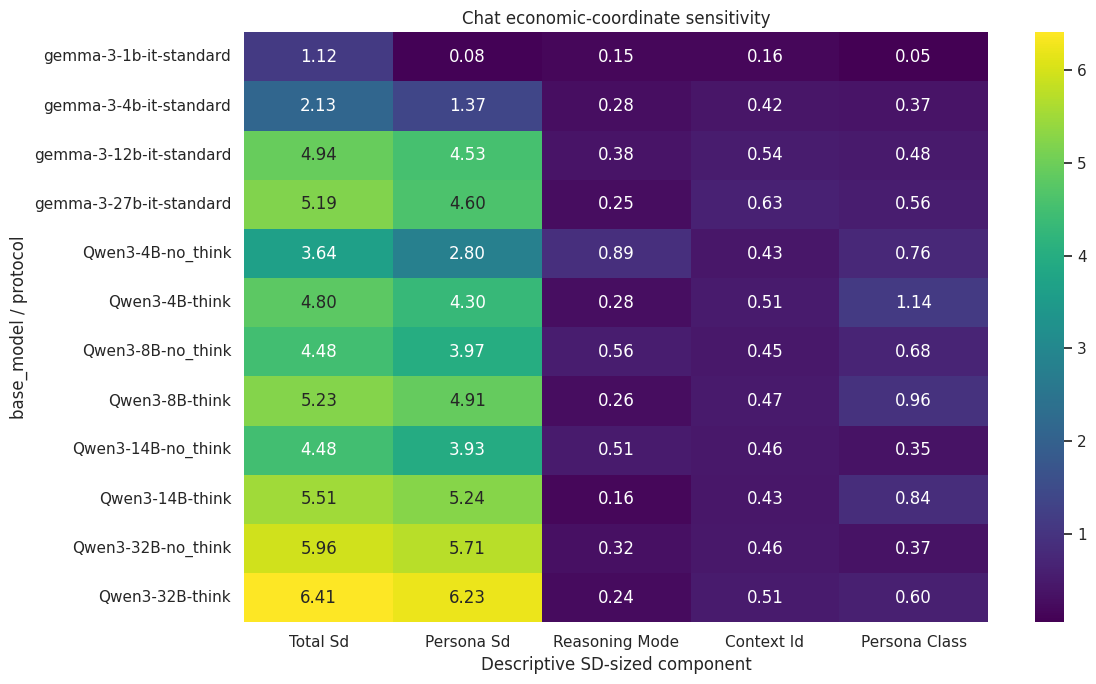

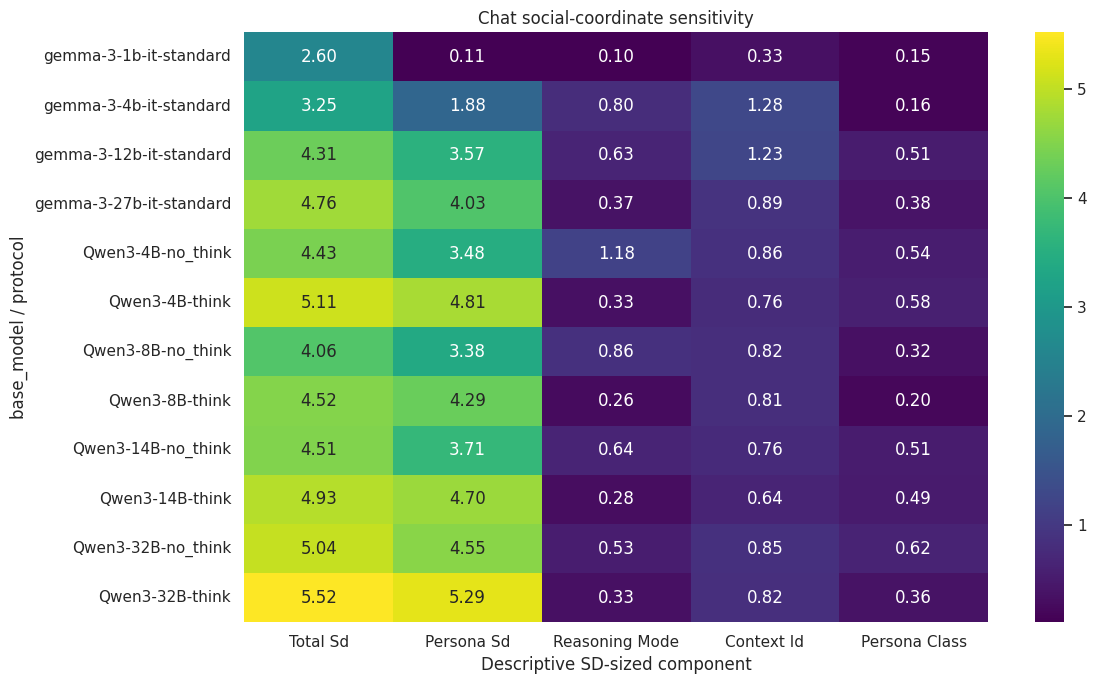

In [6]:
chat_factors=('reasoning_mode','context_id','persona_class')
spread=descriptive_factor_spread(chat,('economic','social'),chat_factors)
display(spread.round(3))
plot_sensitivity_heatmap(spread,'economic',['base_model','protocol'],
                         'Chat economic-coordinate sensitivity',(12,7)); plt.show()
plot_sensitivity_heatmap(spread,'social',['base_model','protocol'],
                         'Chat social-coordinate sensitivity',(12,7)); plt.show()

## Matched Qwen think/no-think shifts

        The table uses matched LHS configuration keys. Positive coordinate
        deltas mean think mode moved right/up relative to no-think; signs vary
        by persona, so an overall average is insufficient.

In [7]:
keys=['base_model','ideology','lhs_row','reasoning_mode','context_id','persona_class']
wide=chat[chat.base_model.isin(QWEN_MODELS)].pivot_table(index=keys,columns='protocol',
         values=['economic','social','mean_stage1_tokens','mean_entropy'],aggfunc='first').dropna()
shifts=pd.DataFrame(index=wide.index)
for metric in ['economic','social','mean_stage1_tokens','mean_entropy']:
    shifts[metric+'_delta_think_minus_no_think']=wide[(metric,'think')]-wide[(metric,'no_think')]
display(shifts.reset_index().groupby(['base_model','ideology'],observed=True)
        .mean(numeric_only=True).round(3))

lhs_row  context_id  \
base_model ideology                                   
Qwen3-14B  authoritarian_left     149.5         0.5   
           authoritarian_right    149.5         0.5   
           base                   149.5         0.5   
           centrism               149.5         0.5   
           libertarian_left       149.5         0.5   
           libertarian_right      149.5         0.5   
Qwen3-32B  authoritarian_left     149.5         0.5   
           authoritarian_right    149.5         0.5   
           base                   149.5         0.5   
           centrism               149.5         0.5   
           libertarian_left       149.5         0.5   
           libertarian_right      149.5         0.5   
Qwen3-4B   authoritarian_left     149.5         0.5   
           authoritarian_right    149.5         0.5   
           base                   149.5         0.5   
           centrism               149.5         0.5   
           libertarian_left       149.5         0.5   
           libertarian_right      149.5         0.5   
Qwen3-8B   authoritarian_left     149.5         0.5   
           authoritarian_right    149.5         0.5   
           base                   149.5         0.5   
           centrism               149.5         0.5   
           libertarian_left       149.5         0.5   
           libertarian_right      149.5         0.5   

                                economic_delta_think_minus_no_think  \
base_model ideology                                                   
Qwen3-14B  authoritarian_left                                -2.062   
           authoritarian_right                                0.946   
           base                                              -1.448   
           centrism                                          -0.444   
           libertarian_left                                  -0.101   
           libertarian_right                                  2.169   
Qwen3-32B  authoritarian_left                                -0.827   
           authoritarian_right                                0.337   
           base                                              -1.466   
           centrism                                          -0.869   
           libertarian_left                                   0.443   
           libertarian_right                                  0.858   
Qwen3-4B   authoritarian_left                                -2.745   
           authoritarian_right                                0.283   
           base                                              -1.601   
           centrism                                          -0.972   
           libertarian_left                                  -1.047   
           libertarian_right                                  2.062   
Qwen3-8B   authoritarian_left                                -1.412   
           authoritarian_right                                0.787   
           base                                              -1.418   
           centrism                                          -0.655   
           libertarian_left                                  -0.097   
           libertarian_right                                  1.247   

                                social_delta_think_minus_no_think  \
base_model ideology                                                 
Qwen3-14B  authoritarian_left                               0.454   
           authoritarian_right                              1.419   
           base                                            -1.442   
           centrism                                        -0.758   
           libertarian_left                                -1.521   
           libertarian_right                               -0.974   
Qwen3-32B  authoritarian_left                               0.684   
           authoritarian_right                              0.815   
           base                                            -1.33

## Quadrant rescues and harms

        A rescue means no-think was outside the assigned persona quadrant and
        think was inside it. A harm is the reverse. This is binary quadrant
        membership—not distance from a quadrant centre, response correctness,
        or rationale quality.

In [8]:
outcomes=qwen_think_outcomes(chat)
outcomes['share']=outcomes.configurations/outcomes.groupby('base_model').configurations.transform('sum')
order=['rescue','harm','both_correct','both_incorrect']
display(outcomes.pivot(index='base_model',columns='outcome',values='share').reindex(QWEN_MODELS)[order].round(3))

outcome,rescue,harm,both_correct,both_incorrect
base_model,,,,
Qwen3-4B,0.127,0.047,0.418,0.408
Qwen3-8B,0.126,0.028,0.451,0.395
Qwen3-14B,0.064,0.037,0.442,0.457
Qwen3-32B,0.039,0.007,0.562,0.392


## Interpretation boundary

        Think mode produces recurring rescues and harms, with directions that
        depend on model and persona/proposition exposure. These diagnostics do
        not support a uniformly beneficial protocol or a simple monotonic size
        effect.